In [1]:
import pandas as pd
import numpy as np

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [2]:
PROJECT_ROOT = Path.cwd().parent

FEATURES_PATH = (
    PROJECT_ROOT /
    "outputs" /
    "natural_sound_features.csv"
)

features_df = pd.read_csv(FEATURES_PATH)

print(features_df.shape)

features_df.head()

(520, 14)


,mean,std,min,max,skewness,kurtosis,rms,entropy,zcr,spectral_centroid,spectral_bandwidth,spectral_rolloff,filename,category
0,-0.000001,0.061434,-0.480499,0.545563,0.392988,10.404342,0.061434,2.948086,0.157994,4042.281204,2643.109696,6623.483383,1-100038-A-14.wav,chirping_birds
1,-0.000003,0.010946,-0.082306,0.102997,0.157899,8.572530,0.010946,3.013087,0.027574,2075.738865,3455.603120,4559.843116,1-101296-A-19.wav,thunderstorm
2,-0.000010,0.016860,-0.164459,0.156952,-0.039740,10.883121,0.016860,2.866590,0.028877,1850.646524,3093.555844,3547.033153,1-101296-B-19.wav,thunderstorm
3,-0.000253,0.136177,-0.945587,0.999969,0.027326,2.776779,0.136177,3.313940,0.041329,2675.116865,3530.183905,6261.615656,1-103298-A-9.wav,crow
4,-0.000025,0.063967,-0.816681,0.980133,-0.052734,29.311878,0.063967,2.170481,0.010723,446.951318,1005.672928,696.156966,1-115521-A-19.wav,thunderstorm


In [3]:
print(features_df["category"].unique())

print()

print(features_df["category"].value_counts())

<StringArray>
['chirping_birds',   'thunderstorm',           'crow',  'pouring_water',
    'water_drops',           'wind',           'frog', 'crackling_fire',
           'rain',        'insects',        'rooster',      'sea_waves',
       'crickets']
Length: 13, dtype: str

category
chirping_birds    40
thunderstorm      40
crow              40
pouring_water     40
water_drops       40
wind              40
frog              40
crackling_fire    40
rain              40
insects           40
rooster           40
sea_waves         40
crickets          40
Name: count, dtype: int64


In [4]:
feature_columns = [

    "mean",
    "std",
    "min",
    "max",

    "skewness",
    "kurtosis",

    "rms",

    "entropy",

    "zcr",

    "spectral_centroid",
    "spectral_bandwidth",
    "spectral_rolloff"

]

X = features_df[feature_columns]

print(X.shape)

(520, 12)


In [5]:
encoder = LabelEncoder()

y = encoder.fit_transform(
    features_df["category"]
)

print(y[:20])

[ 0 10 10  3 10  6 11 11 11 12  4  4 11  1  7  1  5  1  1  1]


In [6]:
mapping = pd.DataFrame({
    "Category": encoder.classes_,
    "Encoded": range(len(encoder.classes_))
})

mapping

,Category,Encoded
0,chirping_birds,0
1,crackling_fire,1
2,crickets,2
3,crow,3
4,frog,4
5,insects,5
6,pouring_water,6
7,rain,7
8,rooster,8
9,sea_waves,9


In [7]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

print(X_train.shape)
print(X_test.shape)

(416, 12)
(104, 12)


In [8]:
rf_model = RandomForestClassifier(

    n_estimators=200,

    random_state=42

)

rf_model.fit(
    X_train,
    y_train
)

print("Training Completed")

Training Completed


In [9]:
y_pred = rf_model.predict(
    X_test
)

print(y_pred[:20])

[ 4  6 12  3 11 10  6  7  8  1 11  9 11  8  8  4  3 12  9  5]


In [10]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)

Accuracy: 0.6057692307692307


In [11]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=encoder.classes_
    )
)

                precision    recall  f1-score   support

chirping_birds       0.60      0.38      0.46         8
crackling_fire       0.80      0.50      0.62         8
      crickets       0.75      0.75      0.75         8
          crow       0.30      0.38      0.33         8
          frog       1.00      0.50      0.67         8
       insects       0.50      0.50      0.50         8
 pouring_water       0.83      0.62      0.71         8
          rain       0.62      0.62      0.62         8
       rooster       0.88      0.88      0.88         8
     sea_waves       0.71      0.62      0.67         8
  thunderstorm       0.50      0.75      0.60         8
   water_drops       0.56      0.62      0.59         8
          wind       0.43      0.75      0.55         8

      accuracy                           0.61       104
     macro avg       0.65      0.61      0.61       104
  weighted avg       0.65      0.61      0.61       104



In [12]:
cm = confusion_matrix(
    y_test,
    y_pred
)

cm

array([[3, 0, 1, 2, 0, 1, 0, 1, 0, 0, 0, 0, 0],
       [0, 4, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1],
       [0, 0, 6, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1],
       [1, 0, 0, 3, 0, 0, 0, 0, 1, 1, 0, 0, 2],
       [1, 0, 0, 2, 4, 0, 0, 0, 0, 0, 0, 0, 1],
       [0, 0, 0, 1, 0, 4, 0, 1, 0, 0, 0, 1, 1],
       [0, 1, 0, 0, 0, 0, 5, 0, 0, 0, 0, 2, 0],
       [0, 0, 1, 0, 0, 1, 0, 5, 0, 1, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 7, 0, 1, 0, 0],
       [0, 0, 0, 1, 0, 1, 0, 1, 0, 5, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 6, 0, 2],
       [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 5, 0],
       [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 6]])

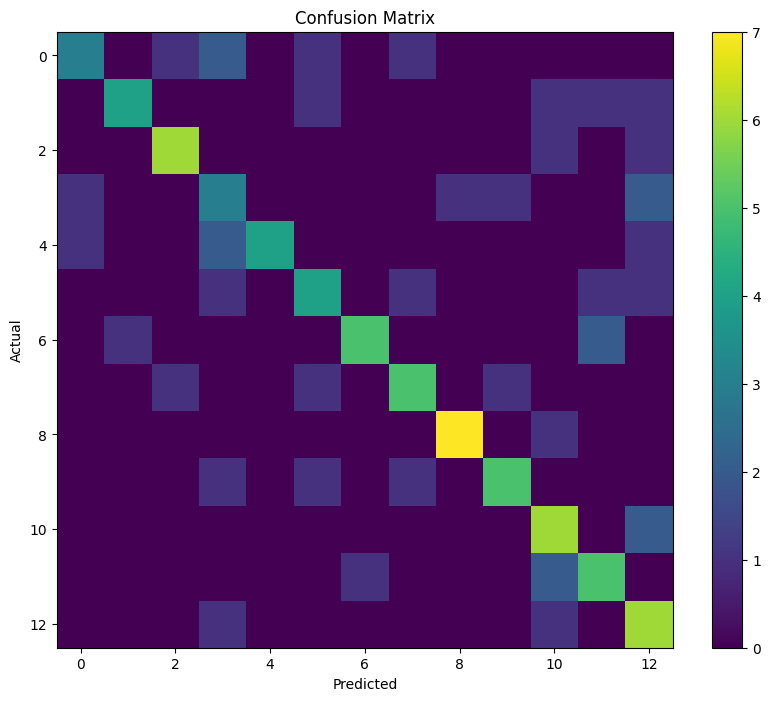

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

plt.imshow(
    cm,
    interpolation="nearest"
)

plt.colorbar()

plt.title(
    "Confusion Matrix"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.show()

In [14]:
importance_df = pd.DataFrame({

    "Feature": feature_columns,

    "Importance": rf_model.feature_importances_

})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df

,Feature,Importance
8,zcr,0.122773
7,entropy,0.115886
5,kurtosis,0.115690
9,spectral_centroid,0.097274
11,spectral_rolloff,0.090421
10,spectral_bandwidth,0.079162
2,min,0.071150
3,max,0.068381
4,skewness,0.063598
1,std,0.060216


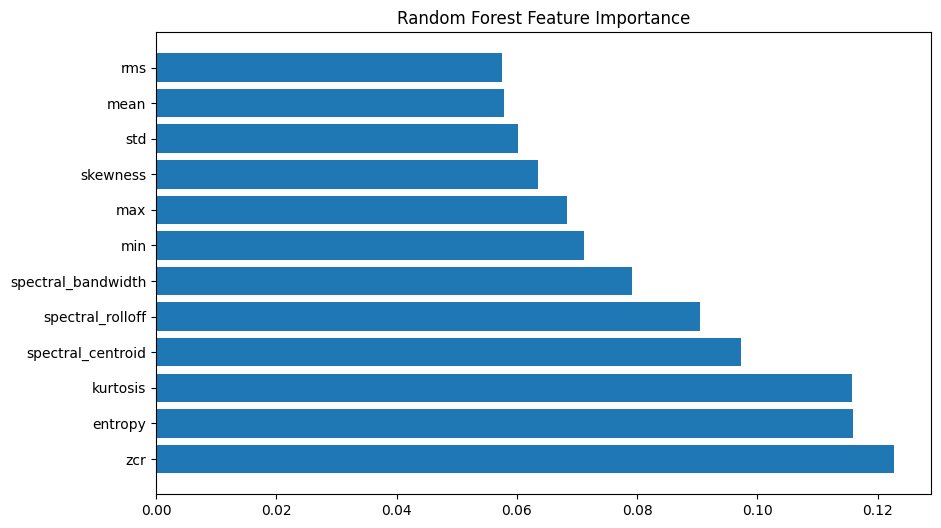

In [15]:
plt.figure(figsize=(10,6))

plt.barh(

    importance_df["Feature"],

    importance_df["Importance"]

)

plt.title(
    "Random Forest Feature Importance"
)

plt.show()

In [16]:
import joblib

joblib.dump(
    rf_model,
    PROJECT_ROOT / "outputs" / "natural_sound_classifier.pkl"
)

print("Model Saved Successfully")

Model Saved Successfully


In [17]:
joblib.dump(
    encoder,
    PROJECT_ROOT / "outputs" / "label_encoder.pkl"
)

print("Encoder Saved Successfully")

Encoder Saved Successfully


In [18]:
import os

for file in os.listdir(PROJECT_ROOT / "outputs"):
    print(file)

label_encoder.pkl
natural_sound_classifier.pkl
natural_sound_features.csv


In [19]:
loaded_model = joblib.load(
    PROJECT_ROOT / "outputs" / "natural_sound_classifier.pkl"
)

loaded_encoder = joblib.load(
    PROJECT_ROOT / "outputs" / "label_encoder.pkl"
)

print(type(loaded_model))
print(type(loaded_encoder))

<class 'sklearn.ensemble._forest.RandomForestClassifier'>
<class 'sklearn.preprocessing._label.LabelEncoder'>


In [20]:
sample = X_test.iloc[[0]]

prediction = loaded_model.predict(sample)

print(prediction)

[4]


In [21]:
decoded_prediction = loaded_encoder.inverse_transform(
    prediction
)

print(decoded_prediction)

['frog']
